<a href="https://colab.research.google.com/github/suryaperumal2004-creator/objection-tracking-using-yolo/blob/main/object_tracking_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import libraries

In [4]:
# Core libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Main deep learning library
#For numerical operations (arrays, math)
#For plotting graphs and images

# Dataset
from tensorflow.keras.datasets import cifar10

#CIFAR-10 image dataset

# Model and layers
from tensorflow.keras import layers, models

#To build neural network models

# Pretrained model
from tensorflow.keras.applications import MobileNetV2

#Pretrained CNN model

# Utilities
from sklearn.metrics import classification_report, confusion_matrix

# Evaluation matrics
import seaborn as sns

# For better visualization (like heatmaps)

load dataset

In [5]:
# Load CIFAR-10 dataset (automatically split into train and te
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

#x_train training images
#y_train labels for training images
#x_test testing images
#y_test labels for testing images

# Print shapes to understand the data structure
print("Train shape:", x_train.shape)
# Example: (50000, 32, 32, 3) 50k images, each 32x32 with 3 0
print("Test shape:", x_test.shape)
# Example: (10000, 32, 32, 3)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


In [6]:
data_augmentation = tf.keras.Sequential ([
layers.RandomFlip("horizontal"),
layers.RandomRotation(0.1),
layers.RandomZoom (0.1)
])

In [7]:
base_model = MobileNetV2(input_shape=(32, 32, 3),
                         include_top=False,
                         weights='imagenet')
base_model.trainable = False

/tmp/ipykernel_8251/2587518058.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(32, 32, 3),


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [9]:
#Build custom model on top of the pretrained base model

model=models.Sequential([

data_augmentation,#Apply random transformations to input images

base_model,#Use pretrained MobileNetV2 as feature extractor

layers.GlobalAveragePooling2D(), # Convert feature maps into a single vector

layers.BatchNormalization(),#Normalize values to make training stable

layers.Dense (128, activation = 'relu'), #Fully connected layer for learning pattens

layers.Dropout (0.5),#Randomly drop neurons to reduce overfitting

# Output layer for 10 classes

layers.Dense(10, activation='softmax')

]) # Closing bracket for models.Sequential

#Display model architecture

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
# Compile the model (configure how it learns)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),  # Optimizer to update weights
    loss='sparse_categorical_crossentropy',  # Loss function for multi-class classification
    metrics=['accuracy']  # Metric to track performance
)

In [13]:
early_stop = tf.keras.callbacks.EarlyStopping(

monitor='val_loss',


patience=3,


restore_best_weights=True
)

In [14]:
history = model.fit(

x_train, y_train,

epochs=10,

validation_data=(x_test, y_test),

callbacks=[early_stop]

)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 95s 56ms/step - accuracy: 0.2690 - loss: 1.9887 - val_accuracy: 0.3152 - val_loss: 2.0657
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 87s 56ms/step - accuracy: 0.2698 - loss: 1.9893 - val_accuracy: 0.3083 - val_loss: 2.0847
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 56ms/step - accuracy: 0.2748 - loss: 1.9832 - val_accuracy: 0.3187 - val_loss: 2.0647
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 90s 58ms/step - accuracy: 0.2735 - loss: 1.9879 - val_accuracy: 0.3124 - val_loss: 2.0963
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 87s 56ms/step - accuracy: 0.2731 - loss: 1.9841 - val_accuracy: 0.3146 - val_loss: 2.0860
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 152s 62ms/step - accuracy: 0.2730 - loss: 1.9827 - val_accuracy: 0.3154 - val_loss: 2.0758


In [16]:
# Unfreeze top layers of base model

base_model.trainable = True

# Freeze initial layers, train only deeper layers

for layer in base_model.layers[:100]:
    layer.trainable = False

# Recompile with lower learning rate

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train again

model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 231s 137ms/step - accuracy: 0.1415 - loss: 3.5910 - val_accuracy: 0.1087 - val_loss: 2.4732
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 212s 136ms/step - accuracy: 0.1819 - loss: 2.7554 - val_accuracy: 0.2168 - val_loss: 2.1415
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 215s 138ms/step - accuracy: 0.2079 - loss: 2.3803 - val_accuracy: 0.2863 - val_loss: 2.0272
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 211s 135ms/step - accuracy: 0.2331 - loss: 2.1879 - val_accuracy: 0.3348 - val_loss: 1.9316
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 212s 135ms/step - accuracy: 0.2550 - loss: 2.0825 - val_accuracy: 0.3546 - val_loss: 1.8547


313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 55ms/step
              precision    recall  f1-score   support

           0       0.33      0.46      0.38      1000
           1       0.45      0.45      0.45      1000
           2       0.24      0.15      0.18      1000
           3       0.27      0.15      0.19      1000
           4       0.31      0.25      0.27      1000
           5       0.40      0.31      0.35      1000
           6       0.43      0.36      0.39      1000
           7       0.35      0.45      0.39      1000
           8       0.35      0.45      0.39      1000
           9       0.37      0.52      0.43      1000

    accuracy                           0.35     10000
   macro avg       0.35      0.35      0.34     10000
weighted avg       0.35      0.35      0.34     10000



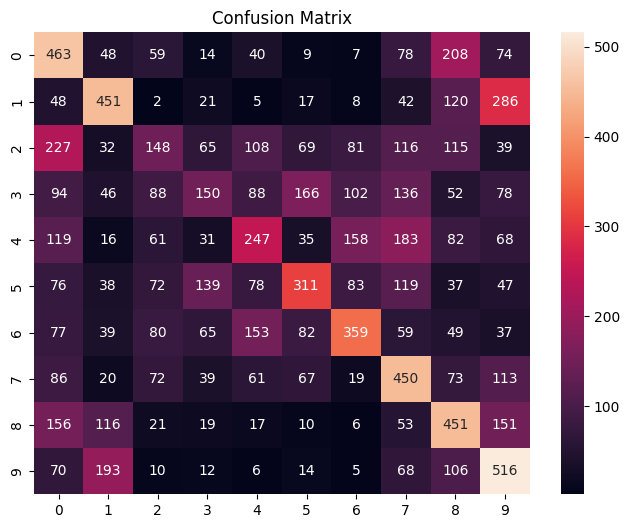

In [17]:
# Predictions

y_pred = np.argmax(model.predict(x_test), axis=1)

# Classification report

print(classification_report(y_test, y_pred))

# Confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.show()

In [18]:
pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.8 MB/s eta 0:00:00


In [19]:
#Load YOLO model

from ultralytics import YOLO

yolo_model = YOLO('yolov8n.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [21]:
#Run detection on image

results = yolo_model('https://ultralytics.com/images/bus.jpg',

save=True)


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 459.2ms
Speed: 16.2ms preprocess, 459.2ms inference, 54.0ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict


In [23]:
# Count detected objects

for r in results:
    print("Objects detected:", len(r.boxes))

Objects detected: 6


In [25]:
from google.colab import files

uploaded = files.upload()

for img in uploaded.keys():

    results = yolo_model(img, save=True)

Saving imas.jpg to imas.jpg

image 1/1 /content/imas.jpg: 448x640 29 cars, 1 bus, 897.0ms
Speed: 27.4ms preprocess, 897.0ms inference, 2.2ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict
